In [ ]:
# ===============================
# 1. IMPORT REQUIRED LIBRARIES
# ===============================
import pandas as pd
import time
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, f1_score

In [15]:
# ===============================
# 2. LOAD DATASET
# ===============================
data = pd.read_csv("C:/Users/dhaks/OneDrive/Desktop/gdm/WINTER '26/TXT MINE/IMDB Dataset.csv")
print("HEAD\n")
print(data.head())

# Convert labels → numeric
data['sentiment'] = data['sentiment'].map({'negative': 0, 'positive': 1})

texts = data['review']
labels = data['sentiment']

HEAD

                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [16]:
# ===============================
# 3. TRAIN-TEST SPLIT
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

# ===============================
# 4. TF-IDF (COMPRESSION)
# ===============================
vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# ===============================
# 5. TF-IDF DETAILS
# ===============================
print("\n--- TF-IDF Details ---")
print("Number of features:", len(vectorizer.get_feature_names_out()))
print("TF-IDF Matrix Shape:", X_train_tfidf.shape)
print("Sample features:", vectorizer.get_feature_names_out()[:10])

# ===============================
# 6. TOP IMPORTANT WORDS
# ===============================
feature_names = vectorizer.get_feature_names_out()
top_indices = np.argsort(X_train_tfidf.sum(axis=0)).A1[::-1][:10]

print("\nTop Important Words:")
for i in top_indices:
    print(feature_names[i])


--- TF-IDF Details ---
Number of features: 5000
TF-IDF Matrix Shape: (40000, 5000)
Sample features: ['00' '000' '10' '100' '11' '12' '13' '13th' '14' '15']

Top Important Words:
the
and
br
of
to
is
it
in
this
that


In [17]:
# ===============================
# 7. BASELINE MODEL (NAIVE BAYES)
# ===============================
print("\n--- Naive Bayes ---")

start = time.time()

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

end = time.time()

nb_accuracy = accuracy_score(y_test, nb_pred)
nb_f1 = f1_score(y_test, nb_pred)
nb_time = end - start

print("Accuracy:", nb_accuracy)
print("F1 Score:", nb_f1)
print("Execution Time:", nb_time)


--- Naive Bayes ---
Accuracy: 0.8517
F1 Score: 0.8525698379560592
Execution Time: 0.03294849395751953


In [18]:
# ===============================
# 8. ADAPTIVE MODEL (SGD - INCREMENTAL)
# ===============================
print("\n--- SGD Classifier (Incremental Learning) ---")

sgd_model = SGDClassifier()

start = time.time()

batch_size = 1000
classes = [0, 1]

for i in range(0, X_train_tfidf.shape[0], batch_size):
    X_batch = X_train_tfidf[i:i+batch_size]
    y_batch = y_train.iloc[i:i+batch_size]
    
    if i == 0:
        sgd_model.partial_fit(X_batch, y_batch, classes=classes)
    else:
        sgd_model.partial_fit(X_batch, y_batch)

sgd_pred = sgd_model.predict(X_test_tfidf)

end = time.time()

sgd_accuracy = accuracy_score(y_test, sgd_pred)
sgd_f1 = f1_score(y_test, sgd_pred)
sgd_time = end - start

print("Accuracy:", sgd_accuracy)
print("F1 Score:", sgd_f1)
print("Execution Time:", sgd_time)


--- SGD Classifier (Incremental Learning) ---
Accuracy: 0.8889
F1 Score: 0.8925220083196285
Execution Time: 0.05996561050415039


In [19]:
# ===============================
# 9. FINAL COMPARISON TABLE
# ===============================
print("\n--- Comparison Table ---")

comparison = pd.DataFrame({
    "Model": ["Naive Bayes", "SGD (Incremental)"],
    "Accuracy": [nb_accuracy, sgd_accuracy],
    "F1 Score": [nb_f1, sgd_f1],
    "Execution Time": [nb_time, sgd_time]
})

print("Naive Bayes vs SGD (Incremental)")

print(comparison)


--- Comparison Table ---
Naive Bayes vs SGD (Incremental)
               Model  Accuracy  F1 Score  Execution Time
0        Naive Bayes    0.8517  0.852570        0.032948
1  SGD (Incremental)    0.8889  0.892522        0.059966


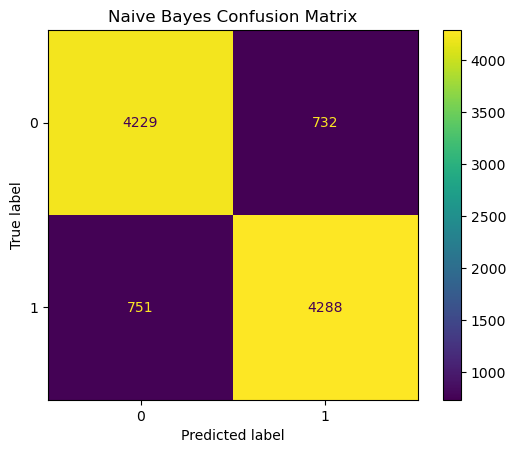

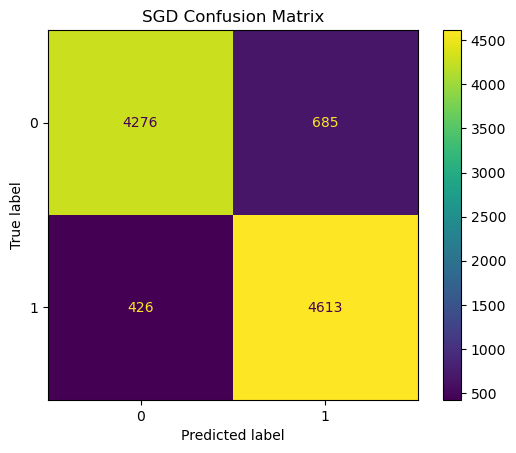

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_nb = confusion_matrix(y_test, nb_pred)

disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb)
disp_nb.plot()
plt.title("Naive Bayes Confusion Matrix")
plt.show()

cm_sgd = confusion_matrix(y_test, sgd_pred)

disp_sgd = ConfusionMatrixDisplay(confusion_matrix=cm_sgd)
disp_sgd.plot()
plt.title("SGD Confusion Matrix")
plt.show()